# **CENG 463 – Introduction to Machine Learning HW2**

## **TASK 1: BAG OF WORDS**

Economy Word Counts: {'victory': 0, 'team': 0, 'fan': 0, 'export': 5, 'sector': 3, 'product': 3, 'committee': 0, 'party': 0, 'law': 0}
Sports Word Counts: {'victory': 3, 'team': 5, 'fan': 3, 'export': 0, 'sector': 0, 'product': 0, 'committee': 0, 'party': 0, 'law': 0}
Politics Word Counts: {'victory': 0, 'team': 0, 'fan': 0, 'export': 0, 'sector': 0, 'product': 0, 'committee': 5, 'party': 4, 'law': 5}


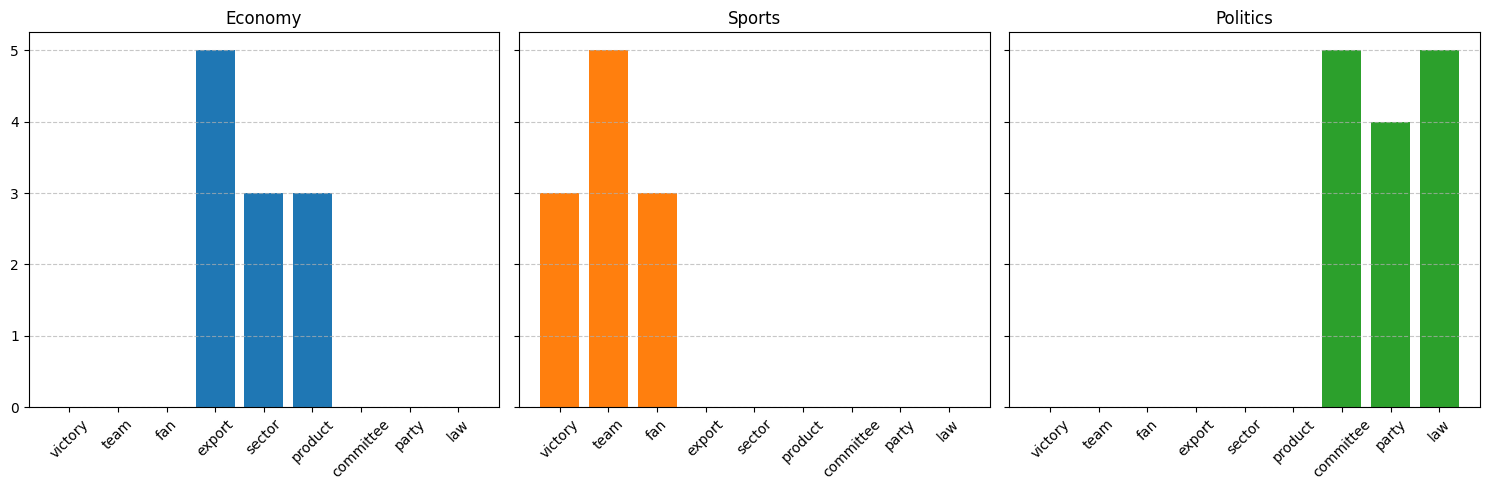

In [102]:
import matplotlib.pyplot as plt
import string
vocab = ["victory", "team", "fan", "export", "sector", "product", "committee", "party", "law"]
def count_word_in_vocab(vocab, text):
    word_count = {}
    text = text.lower()
    for char in string.punctuation:
        text = text.replace(char, ' ')
    words = text.lower().split()
    for v in vocab:
        count = 0
        for w in words:
            if w == v or w == v + 's': #plural form for example "fans" in sports
                count += 1
        word_count[v] = count
        
    return word_count

def read_file_and_count_words(file, vocab):
    with open(file, 'r') as file:
        text = file.read()
    return count_word_in_vocab(vocab, text)

def main():
    economyDict = read_file_and_count_words('economy.txt', vocab)
    sportsDict = read_file_and_count_words('sports.txt', vocab)
    politicsDict = read_file_and_count_words('politics.txt', vocab)
    print("Economy Word Counts:", economyDict)
    print("Sports Word Counts:", sportsDict)
    print("Politics Word Counts:", politicsDict)
    docs = ["Economy", "Sports", "Politics"]
    data_dicts = [economyDict, sportsDict, politicsDict]
    colors = ['tab:blue', 'tab:orange', 'tab:green']

    fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

    for i in range(3):
        ax = axes[i]
        current_dict = data_dicts[i]
        # keys are words, values are counts
        ax.bar(current_dict.keys(), current_dict.values(), color=colors[i])
        ax.set_title(docs[i])
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()



if __name__ == "__main__":
    main()
    

Here we counted the occurences in each text file and then logged them into a dictionary
this dictionary for each text file is then later used when plotting the bag of words frequency vector (histograms)
we also needed to count simple plural forms because there exists words in plural forms and without this plural counting we did not actually get
the right amount of occurences.

## **TASK 2: TEXT CLASSIFICATION**

In [130]:
import pandas as pd
import string


raw_data = [
    {"doc_id": "d1", "text": "free, free, free, buy. discount, combo, pleasure.", "class": "S", "type": "Train"},
    {"doc_id": "d2", "text": "free, free, free, discount. pleasure, smile, smile, smile", "class": "S", "type": "Train"},
    {"doc_id": "d3", "text": "cat, mouse", "class": "N", "type": "Train"},
    {"doc_id": "d4", "text": "cat, cat, dog, dog, dog, dog", "class": "N", "type": "Train"},
    {"doc_id": "d5", "text": "mouse", "class": "N", "type": "Train"},
    {"doc_id": "d6", "text": "dog, cat, mouse, cat", "class": "?", "type": "Test"},
    {"doc_id": "d7", "text": "Free, free, smile", "class": "?", "type": "Test"}
]

df = pd.DataFrame(raw_data)

def preprocess_text(text):
    text = text.lower() # "Free" -> "free"
    for char in string.punctuation:
        text = text.replace(char, ' ')
    return text.split()

df['words'] = df['text'].apply(preprocess_text)

print(df[['doc_id', 'words', 'class']])

  doc_id                                              words class
0     d1  [free, free, free, buy, discount, combo, pleas...     S
1     d2  [free, free, free, discount, pleasure, smile, ...     S
2     d3                                       [cat, mouse]     N
3     d4                     [cat, cat, dog, dog, dog, dog]     N
4     d5                                            [mouse]     N
5     d6                             [dog, cat, mouse, cat]     ?
6     d7                                [free, free, smile]     ?


### **Step 1: Chi-Square Feature Selection**

In [ ]:
train_df = df[df['type'] == 'Train']

spam_words = []
normal_words = []

for index, row in train_df.iterrows():
    if row['class'] == 'S':
        spam_words.extend(row['words'])
    elif row['class'] == 'N':
        normal_words.extend(row['words'])

# 3. Calculate Totals
N_spam = len(spam_words)    #should be 15
N_normal = len(normal_words) #should be 9
N_total = N_spam + N_normal

print(f"Total words in Spam: {N_spam}")
print(f"Total words in Normal: {N_normal}")

# 4. Calculate Chi-Square for every word
vocabulary = set(spam_words + normal_words)
chi_square_scores = {}

for word in vocabulary:
    #observed counts
    O_spam = spam_words.count(word)
    O_normal = normal_words.count(word)
    
    count_w = O_spam + O_normal
    
    #expected counts (based on class probability)
    E_spam = (count_w / N_total) * N_spam
    E_normal = (count_w / N_total) * N_normal
    
    #we add a small epsilon 1e-9 to avoid division by zero if E is 0 (though unlikely here)
    chi_sq = ((O_spam - E_spam)**2 / (E_spam + 1e-9)) + \
             ((O_normal - E_normal)**2 / (E_normal + 1e-9))
    
    chi_square_scores[word] = chi_sq

#5. Sort and Print Results
sorted_scores = sorted(chi_square_scores.items(), key=lambda x: x[1], reverse=True)

print("\n--- Top Discriminative Words (Chi-Square Scores) ---")
for word, score in sorted_scores:
    print(f"{word}: {score:.4f}")

# 6. Save top features for the next step, lets pick top 3
selected_features = [word for word, score in sorted_scores[:3]]
print(f"\nSelected Features for Step 2: {selected_features}")

Total words in Spam: 15
Total words in Normal: 9

--- Top Discriminative Words (Chi-Square Scores) ---
dog: 6.6667
cat: 5.0000
free: 3.6000
mouse: 3.3333
smile: 1.8000
discount: 1.2000
pleasure: 1.2000
combo: 0.6000
buy: 0.6000

Selected Features for Step 2: ['dog', 'cat', 'free']


### **Step 2: TF-IDF Representation**

In [ ]:
import pandas as pd
import math
import string

raw_data = [
    {"doc_id": "d1", "text": "free, free, free, buy. discount, combo, pleasure.", "class": "S", "type": "Train"},
    {"doc_id": "d2", "text": "free, free, free, discount. pleasure, smile, smile, smile", "class": "S", "type": "Train"},
    {"doc_id": "d3", "text": "cat, mouse", "class": "N", "type": "Train"},
    {"doc_id": "d4", "text": "cat, cat, dog, dog, dog, dog", "class": "N", "type": "Train"},
    {"doc_id": "d5", "text": "mouse", "class": "N", "type": "Train"},
    {"doc_id": "d6", "text": "dog, cat, mouse, cat", "class": "?", "type": "Test"},
    {"doc_id": "d7", "text": "Free, free, smile", "class": "?", "type": "Test"}
]
df = pd.DataFrame(raw_data)

def preprocess_text(text):
    text = text.lower()
    for char in string.punctuation:
        text = text.replace(char, ' ')
    return text.split()

df['words'] = df['text'].apply(preprocess_text)

#1. Define Selected Features (Top 3 from Step 1)
selected_features = ['dog', 'cat', 'free']          #TODO: EREN BURA BAK BABA, DİREKT KENDİMİZ KOYMAK YERİNE SEÇMEK DAHA İYİ OLABİLİR

#2. Calculate IDF
N = len(df)
idf_values = {}

for word in selected_features:
    doc_count = sum(1 for words in df['words'] if word in words)
    if doc_count > 0:
        idf_values[word] = math.log10(N / doc_count)
    else:
        idf_values[word] = 0

#3. Calculate TF-IDF (WITH THE FIX)
tfidf_table = []

for index, row in df.iterrows():
    doc_id = row['doc_id']
    words = row['words']
    total_words = len(words)
    
    #FIX: We now include 'Type' so Step 3 can read it
    table_row = {
        'Document': doc_id, 
        'Class': row['class'], 
        'Type': row['type'] 
    }
    
    for word in selected_features:
        tf = words.count(word) / total_words
        idf = idf_values[word]
        tfidf = tf * idf
        table_row[word] = round(tfidf, 4)
    
    tfidf_table.append(table_row)

# 4. Create DataFrame
tfidf_df = pd.DataFrame(tfidf_table)
print("\n--- TF-IDF Numerical Feature Matrix ---")
print(tfidf_df)


--- TF-IDF Numerical Feature Matrix ---
  Document Class   Type     dog     cat    free
0       d1     S  Train  0.0000  0.0000  0.1577
1       d2     S  Train  0.0000  0.0000  0.1380
2       d3     N  Train  0.0000  0.1840  0.0000
3       d4     N  Train  0.3627  0.1227  0.0000
4       d5     N  Train  0.0000  0.0000  0.0000
5       d6     ?   Test  0.1360  0.1840  0.0000
6       d7     ?   Test  0.0000  0.0000  0.2453


### **Step 3: KNN Classification**

In [ ]:
import math
import pandas as pd

#if you are running this cell separately make sure 
#the dataframe exists(run the cell before this for dataframe)!!

features = ['dog', 'cat', 'free']
k = 3

def calculate_euclidean_distance(row1, row2, features):
    distance = 0.0
    for feature in features:
        diff = row1[feature] - row2[feature]
        distance += diff * diff
    return math.sqrt(distance)

# 1. Separate Training and Test Data
train_df = tfidf_df[tfidf_df['Type'] == 'Train']
test_df = tfidf_df[tfidf_df['Type'] == 'Test']

print(f"--- KNN Classification Results (k={k}) ---")

# 2. Iterate through each Test Document
for index, test_row in test_df.iterrows():
    test_doc_id = test_row['Document']
    print(f"\nProcessing {test_doc_id}...")
    
    # Calculate distance to ALL training documents
    distances = []
    for _, train_row in train_df.iterrows():
        dist = calculate_euclidean_distance(test_row, train_row, features)
        distances.append({
            'doc_id': train_row['Document'],
            'class': train_row['Class'],
            'distance': dist
        })
    
    # 3. Sort by distance (smallest to largest) and pick top K
    distances.sort(key=lambda x: x['distance'])
    nearest_neighbors = distances[:k]
    
    # 4. Vote for the class
    votes = {'S': 0, 'N': 0}
    print(f"  Nearest Neighbors:")
    for neighbor in nearest_neighbors:
        print(f"    -> {neighbor['doc_id']} (Class: {neighbor['class']}) Distance: {neighbor['distance']:.4f}")
        votes[neighbor['class']] += 1
        
    # 5. Final Prediction
    predicted_class = max(votes, key=votes.get)
    print(f"  > Final Prediction: {predicted_class} (Votes: {votes})")

--- KNN Classification Results (k=3) ---

Processing d6...
  Nearest Neighbors:
    -> d3 (Class: N) Distance: 0.1360
    -> d5 (Class: N) Distance: 0.2288
    -> d4 (Class: N) Distance: 0.2348
  > Final Prediction: N (Votes: {'S': 0, 'N': 3})

Processing d7...
  Nearest Neighbors:
    -> d1 (Class: S) Distance: 0.0876
    -> d2 (Class: S) Distance: 0.1073
    -> d5 (Class: N) Distance: 0.2453
  > Final Prediction: S (Votes: {'S': 2, 'N': 1})


## **TASK 3: TOPIC MODELING WITH BERTOPIC**

### **Step 1: Dataset Creation**

In [ ]:
from sklearn.datasets import fetch_20newsgroups
import pandas as pd
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
#select 3 categories from 20newsgroups
categories = [
    'rec.sport.baseball',      # Sports
    'sci.space',               # Space/Science
    'talk.politics.misc'       # Politics
]

#fetch the dataset
newsgroups = fetch_20newsgroups(
    subset='train',
    categories=categories,
    remove=('headers', 'footers', 'quotes'),  #clean the text
    random_state=42
)

#create a dataframe
df = pd.DataFrame({
    'text': newsgroups.data,
    'category': [newsgroups.target_names[i] for i in newsgroups.target]
})

print(f"Total documents: {len(df)}")
print(f"\nCategories: {df['category'].unique()}")
print(f"\nCategory distribution:\n{df['category'].value_counts()}")
print(f"\nSample document:\n{df['text'].iloc[0][:200]}...")


Total documents: 2756

Categories: ['talk.politics.misc' 'sci.space' 'rec.sport.baseball']

Category distribution:
category
rec.sport.baseball    994
sci.space             987
talk.politics.misc    775
Name: count, dtype: int64

Sample document:


:So we try to ensure that the process of deciding whether to introduce
:third parties isn't random.  As Steve said above, there are examples
:where third parties *are* less ignorant or corrupt than ...


### **Step 2: Model Training**

In [ ]:
print("\n" + "="*80)
print("STEP 2: MODEL CREATION & TRAINING")
print("="*80)

#configure the model
vectorizer_model = CountVectorizer(
    stop_words="english",
    min_df=0.01,  #the word must be in at lest %1 of the documents
    max_df=0.9,   #this ignore words appearing in >90% of documents
    ngram_range=(1, 2)
)

#init bertopic
topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    min_topic_size=10,
    nr_topics='auto',
    language='english',
    calculate_probabilities=True,
    verbose=True
)

#train the model
topics, probs = topic_model.fit_transform(df['text'].tolist())

#add topics to dataframe
df['topic'] = topics

#report number of topics
num_topics = len(set(topics)) - (1 if -1 in topics else 0)
print(f"\nNumber of topics discovered: {num_topics}")

#show topic summary
topic_info = topic_model.get_topic_info()
print(f"\nTopic Summary:")
print(topic_info)

2025-12-15 22:58:50,421 - BERTopic - Embedding - Transforming documents to embeddings.



STEP 2: MODEL CREATION & TRAINING


Batches: 100%|██████████| 87/87 [00:59<00:00,  1.46it/s]
2025-12-15 22:59:54,460 - BERTopic - Embedding - Completed ✓
2025-12-15 22:59:54,462 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-12-15 23:00:12,624 - BERTopic - Dimensionality - Completed ✓
2025-12-15 23:00:12,628 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-12-15 23:00:13,136 - BERTopic - Cluster - Completed ✓
2025-12-15 23:00:13,138 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-12-15 23:00:14,090 - BERTopic - Representation - Completed ✓
2025-12-15 23:00:14,090 - BERTopic - Topic reduction - Reducing number of topics
2025-12-15 23:00:14,107 - BERTopic - Representation - Fine-tuning topics using representation models.
2025-12-15 23:00:15,107 - BERTopic - Representation - Completed ✓
2025-12-15 23:00:15,110 - BERTopic - Topic reduction - Reduced number of topics from 42 to 22



Number of topics discovered: 21

Topic Summary:
    Topic  Count                                        Name  \
0      -1    616               -1_space_launch_president_new   
1       0    917                      0_game_year_games_team   
2       1    447                     1_space_nasa_solar_moon   
3       2    138       2_insurance_government_health_private   
4       3    131                3_people_children_fbi_koresh   
5       4    118                  4_men_sex_homosexuals_male   
6       5     68                                       5____   
7       6     64                      6_ted_people_post_read   
8       7     34                      7_drug_drugs_crime_use   
9       8     27                     8_ms_president_mr_think   
10      9     23                                       9____   
11     10     22               10_oxygen_pressure_space_high   
12     11     21  11_phd_atmospheric_environmental_professor   
13     12     18                      12_sam_yeah_telli

### **Step 3: Topic Analysis**

In [ ]:
print("\nTop 5 words per topic:")
print("-"*60)
topic_names = {}

for topic_num in topic_info['Topic']:
    if topic_num == -1:
        topic_names[-1] = "Outliers"
        continue  #skip outliers
    if words:
        top_words = [word for word, score in words[:5]]
        print(f"Topic {topic_num}: {', '.join(top_words)}")
            
        #sssign meaningful names based on top words
        #TODO: EREN BABA You should manually adjust these based on your actual results
        word_str = ' '.join(top_words).lower()
        if any(w in word_str for w in ['game', 'team', 'play', 'baseball', 'hit']):
            topic_names[topic_num] = "Sports/Baseball"
        elif any(w in word_str for w in ['space', 'nasa', 'orbit', 'launch', 'moon']):
            topic_names[topic_num] = "Space/Science"
        elif any(w in word_str for w in ['government', 'law', 'people', 'state', 'rights']):
            topic_names[topic_num] = "Politics/Government"
        else:
            topic_names[topic_num] = f"Topic_{topic_num}"

#update topic model with custom labels
topic_model.set_topic_labels(topic_names)

#create document-topic mapping table
doc_topic_table = df[['text', 'category', 'topic']].copy()
doc_topic_table['topic_name'] = doc_topic_table['topic'].map(
    lambda x: topic_names.get(x, f"Topic_{x}")
)
doc_topic_table['text_preview'] = doc_topic_table['text'].str[:80] + '...'

print("\nDocument-Topic Mapping (first 10 documents):")
print(doc_topic_table[['text_preview', 'category', 'topic', 'topic_name']].head(10))

print("\nTopic distribution:")
print(doc_topic_table['topic_name'].value_counts())



Top 5 words per topic:
------------------------------------------------------------
Topic 0: game, year, games, team, baseball
Topic 1: space, nasa, solar, moon, earth
Topic 2: insurance, government, health, private, tax
Topic 3: people, children, fbi, koresh, did
Topic 4: men, sex, homosexuals, male, people
Topic 5: , , , , 
Topic 6: ted, people, post, read, thought
Topic 7: drug, drugs, crime, use, users
Topic 8: ms, president, mr, think, going
Topic 9: , , , , 
Topic 10: oxygen, pressure, space, high, falling
Topic 11: phd, atmospheric, environmental, professor, weather
Topic 12: sam, yeah, telling, im, nick
Topic 13: software, process, level, shuttle, engineering
Topic 14: reserve, service, naval, draft, agree
Topic 15: constant, mass, radius, velocity, times
Topic 16: rights, right, association, equal, freedom
Topic 17: command, mode, loss, safe, earth
Topic 18: mystery, grows, hm, tommy, vision
Topic 19: food, space, bar, like, things
Topic 20: school, children, health, conferen

### **Step 4: Visualization**

Bar chart saved as 'topic_barchart.html'
Bar chart saved as 'topic_words_barchart.png'


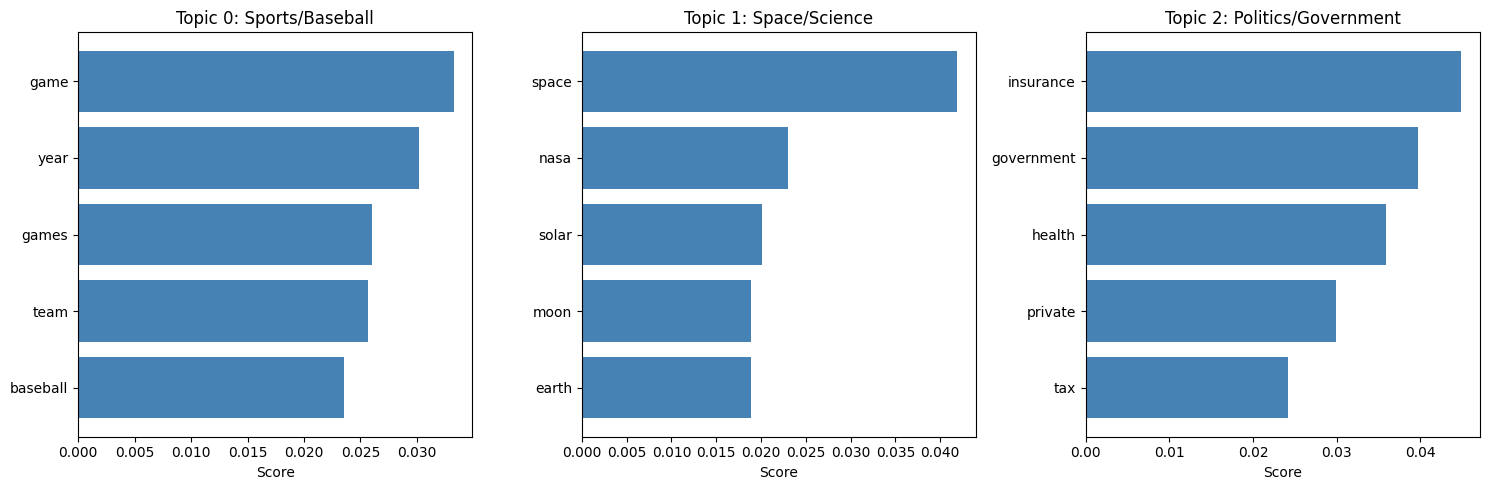

Topic distance map saved as 'topic_distance_map.html'
Topic hierarchy saved as 'topic_hierarchy.html'


In [ ]:
#1. Bar chart of top words per topic
fig = topic_model.visualize_barchart(top_n_topics=num_topics, n_words=10)
fig.show()

#custom matplotlib bar charts
valid_topics = [t for t in topic_info['Topic'] if t != -1][:3]
fig_mpl, axes = plt.subplots(1, len(valid_topics), figsize=(15, 5))
if len(valid_topics) == 1:
    axes = [axes]

for idx, topic_num in enumerate(valid_topics):
    words = topic_model.get_topic(topic_num)
    if words:
        words_list = [word for word, score in words[:5]]
        scores_list = [score for word, score in words[:5]]
        
        axes[idx].barh(words_list, scores_list, color='steelblue')
        axes[idx].set_title(f"Topic {topic_num}: {topic_names.get(topic_num, 'Unknown')}")
        axes[idx].set_xlabel("Score")
        axes[idx].invert_yaxis()

plt.tight_layout()
plt.show()

# 2. Topic distance map
fig = topic_model.visualize_topics()
fig.show()

# 3. Hierarchical clustering
fig = topic_model.visualize_hierarchy()
fig.show()

### **Step 5: New Document Test**

In [ ]:
# Write 3 new articles (one per category)
new_articles = [
    # Sports article
    """The Yankees secured a dramatic victory in the ninth inning yesterday. 
    The team's star pitcher delivered an outstanding performance, striking out 
    12 batters. Fans cheered as the home run sealed the championship game. 
    The baseball season has been incredible with record-breaking attendance.""",
    
    # Space/Science article
    """NASA announced a groundbreaking mission to explore Mars next year. 
    The spacecraft will carry advanced instruments to study the planet's 
    atmosphere and search for signs of ancient life. Astronauts are training 
    for the journey, which will take several months. The mission includes 
    deploying a new rover with cutting-edge technology.""",
    
    # Politics article
    """The government proposed new legislation on healthcare reform today. 
    Congress will debate the bill next week, with both parties presenting 
    their positions. The policy aims to address rising costs and improve 
    access to medical services. Political analysts expect intense discussions 
    in the senate before any vote takes place."""
]

article_labels = ["Sports", "Space", "Politics"]

# Predict topics for new documents
predicted_topics, predicted_probs = topic_model.transform(new_articles)

print("\nNew Document Predictions:")
print("="*60)
for idx, (article, label, topic, prob) in enumerate(
    zip(new_articles, article_labels, predicted_topics, predicted_probs), 1
):
    topic_name = topic_names.get(topic, f"Topic_{topic}")
    confidence = prob.max() if len(prob) > 0 else 0
    
    print(f"\nArticle {idx} ({label}):")
    print(f"Preview: {article[:100]}...")
    print(f"Predicted Topic: {topic} - {topic_name}")
    print(f"Confidence: {confidence:.3f}")
    
    # Check if prediction matches expected category
    match = "CORRECT" if (
        (label == "Sports" and "Sports" in topic_name) or
        (label == "Space" and "Space" in topic_name) or
        (label == "Politics" and ("Politics" in topic_name or "Government" in topic_name))
    ) else "MISMATCH"
    print(f"Result: {match}")

# Summary
print("\n" + "="*60)
print("PREDICTION SUMMARY")
print("="*60)
correct = sum(1 for label, topic in zip(article_labels, predicted_topics) 
              if (label == "Sports" and "Sports" in topic_names.get(topic, "")) or
                 (label == "Space" and "Space" in topic_names.get(topic, "")) or
                 (label == "Politics" and ("Politics" in topic_names.get(topic, "") or "Government" in topic_names.get(topic, ""))))
print(f"Accuracy: {correct}/3 ({correct/3*100:.0f}%)")

Batches: 100%|██████████| 1/1 [00:00<00:00, 15.22it/s]
2025-12-15 23:00:21,152 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-12-15 23:00:21,180 - BERTopic - Dimensionality - Completed ✓
2025-12-15 23:00:21,182 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-12-15 23:00:21,184 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-12-15 23:00:21,186 - BERTopic - Probabilities - Completed ✓
2025-12-15 23:00:21,187 - BERTopic - Cluster - Completed ✓



New Document Predictions:

Article 1 (Sports):
Preview: The Yankees secured a dramatic victory in the ninth inning yesterday. 
    The team's star pitcher d...
Predicted Topic: 0 - Sports/Baseball
Confidence: 0.870
Top 3 topic probabilities:
  Sports/Baseball: 0.870
  Space/Science: 0.046
  Politics/Government: 0.013

Article 2 (Space):
Preview: NASA announced a groundbreaking mission to explore Mars next year. 
    The spacecraft will carry ad...
Predicted Topic: -1 - Topic_-1
Confidence: 0.555
Top 3 topic probabilities:
  Topic_11: 0.555
  Space/Science: 0.288
  Space/Science: 0.000

Article 3 (Politics):
Preview: The government proposed new legislation on healthcare reform today. 
    Congress will debate the bi...
Predicted Topic: -1 - Topic_-1
Confidence: 0.234
Top 3 topic probabilities:
  Space/Science: 0.234
  Politics/Government: 0.106
  Politics/Government: 0.101
